<a href="https://www.kaggle.com/code/sonawanelalitsunil/chocolate-sales-trends-ml?scriptVersionId=226730087" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/chocolate-sales/Chocolate Sales.xlsx
/kaggle/input/chocolate-sales/Chocolate Sales.csv


# Title: Chocolate Sales Trends 📊🍫

## Description: A rich dataset for exploring chocolate sales patterns, seasonal trends, and customer preferences. Perfect for sales analysis and forecasting.

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Use Agg backend
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(style="whitegrid")

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Import Datasets

In [4]:
df = pd.read_csv("/kaggle/input/chocolate-sales/Chocolate Sales.csv")

In [5]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [6]:
df.tail()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
1089,Karlen McCaffrey,Australia,Spicy Special Slims,17-May-22,"$4,410",323
1090,Jehu Rudeforth,USA,White Choc,07-Jun-22,"$6,559",119
1091,Ches Bonnell,Canada,Organic Choco Syrup,26-Jul-22,$574,217
1092,Dotty Strutley,India,Eclairs,28-Jul-22,"$2,086",384
1093,Karlen McCaffrey,India,70% Dark Bites,23-May-22,"$5,075",344


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [8]:
df.describe()

,Boxes Shipped
count,1094.000000
mean,161.797989
std,121.544145
min,1.000000
25%,70.000000
50%,135.000000
75%,228.750000
max,709.000000


In [9]:
df.isnull().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1089    False
1090    False
1091    False
1092    False
1093    False
Length: 1094, dtype: bool

In [11]:
df.corr

<bound method DataFrame.corr of           Sales Person    Country              Product       Date    Amount  \
0       Jehu Rudeforth         UK      Mint Chip Choco  04-Jan-22   $5,320    
1          Van Tuxwell      India        85% Dark Bars  01-Aug-22   $7,896    
2         Gigi Bohling      India  Peanut Butter Cubes  07-Jul-22   $4,501    
3         Jan Morforth  Australia  Peanut Butter Cubes  27-Apr-22  $12,726    
4       Jehu Rudeforth         UK  Peanut Butter Cubes  24-Feb-22  $13,685    
...                ...        ...                  ...        ...       ...   
1089  Karlen McCaffrey  Australia  Spicy Special Slims  17-May-22   $4,410    
1090    Jehu Rudeforth        USA           White Choc  07-Jun-22   $6,559    
1091      Ches Bonnell     Canada  Organic Choco Syrup  26-Jul-22     $574    
1092    Dotty Strutley      India              Eclairs  28-Jul-22   $2,086    
1093  Karlen McCaffrey      India       70% Dark Bites  23-May-22   $5,075    

      Boxes Shipped

In [12]:
df.duplicated().sum()

0

In [13]:
df.columns

Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')

## Data visualizations

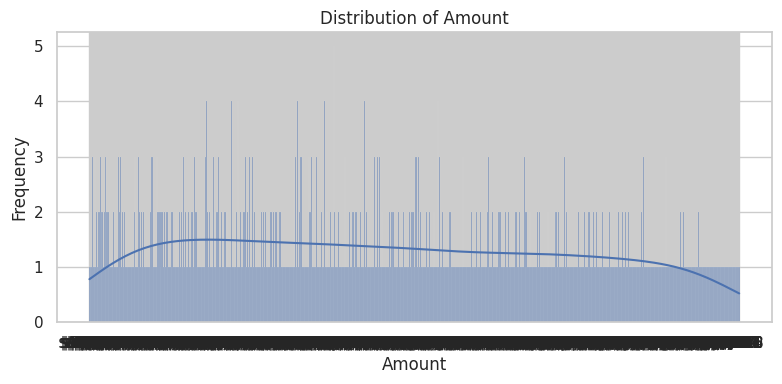

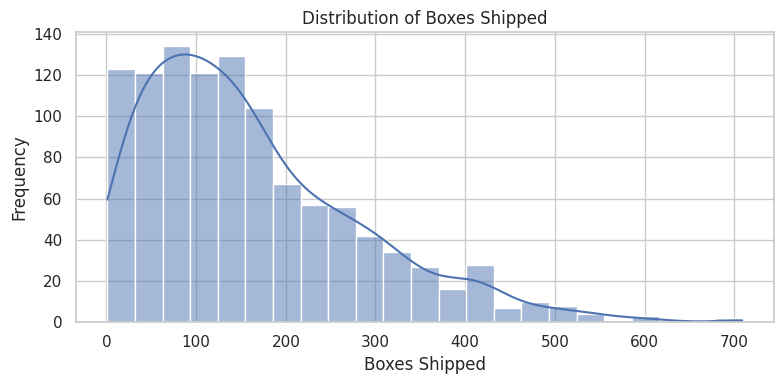

In [14]:
numeric_cols = ['Amount', 'Boxes Shipped']
categorical_cols = ['Sales Person', 'Country', 'Product']

# Plot histograms for numeric variables
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [15]:
print(df.columns)

Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')


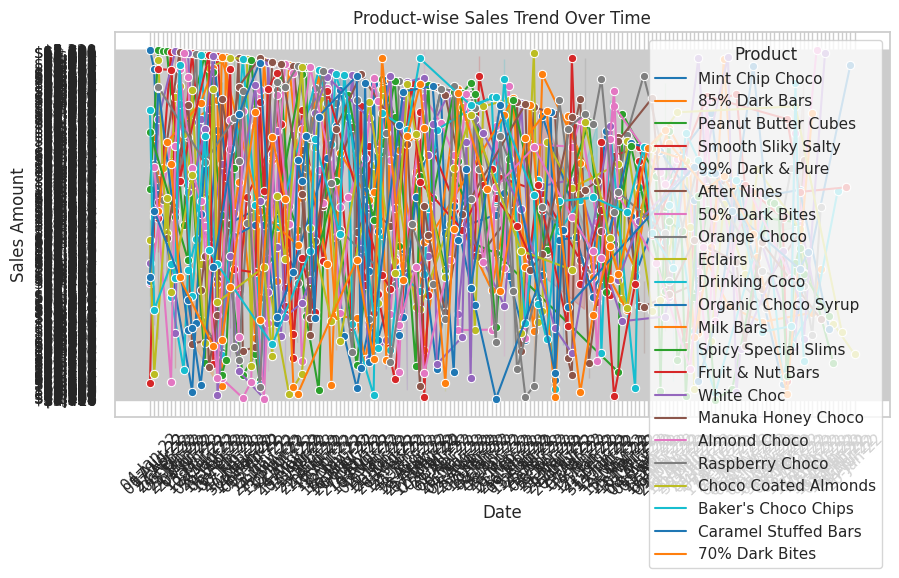

In [16]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='Date', y='Amount', hue='Product', data=df, marker='o', palette='tab10')
plt.title('Product-wise Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.legend(title='Product')
plt.grid(True)
plt.show()

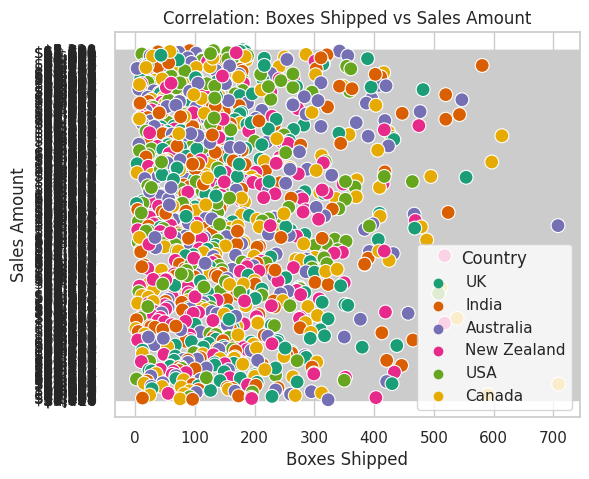

In [17]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='Boxes Shipped', y='Amount', data=df, hue='Country', palette='Dark2', s=100)
plt.title('Correlation: Boxes Shipped vs Sales Amount')
plt.xlabel('Boxes Shipped')
plt.ylabel('Sales Amount')
plt.grid(True)
plt.show()

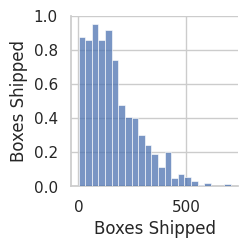

In [18]:
sns.pairplot(df[numeric_cols])
plt.show()

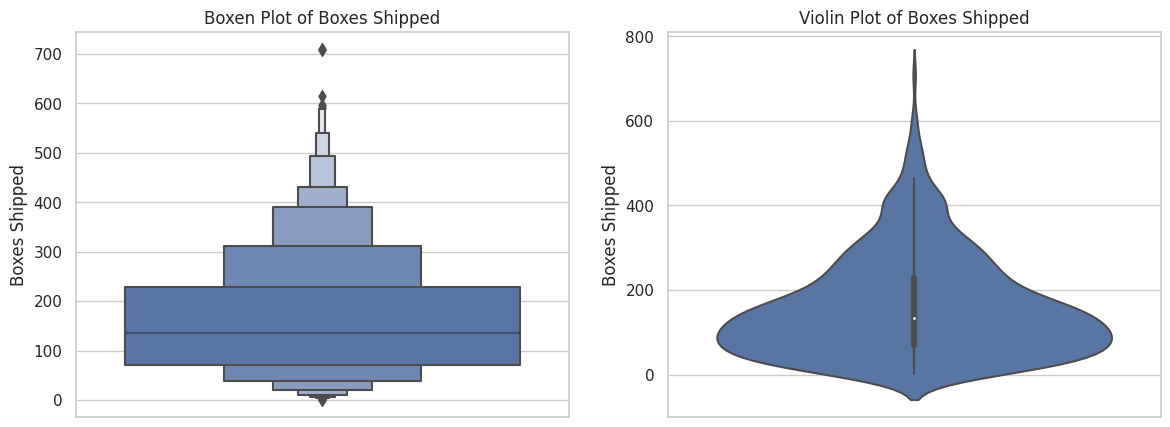

In [19]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

for col in numeric_cols:
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxenplot(y=df[col], ax=ax[0])
    ax[0].set_title(f'Boxen Plot of {col}')

    sns.violinplot(y=df[col], ax=ax[1])
    ax[1].set_title(f'Violin Plot of {col}')

    plt.show()

## Predictive Modeling

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Define features and target
features = ['Sales Person', 'Country', 'Product', 'Amount']
target = 'Boxes Shipped'

# Drop rows with missing values
model_df = df[features + [target]].dropna()

# Split data
X = model_df[features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing
categorical_features = ['Sales Person', 'Country', 'Product']
numeric_features = ['Amount']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('poly', PolynomialFeatures(degree=2, include_bias=False), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regression': SVR()
}

In [21]:
non_numeric = X_train[~X_train.applymap(lambda x: str(x).replace(',', '').replace('.', '').isdigit()).all(axis=1)]
print(non_numeric)

         Sales Person      Country               Product    Amount
6          Oby Sorrel           UK       99% Dark & Pure  $13,685 
789      Ches Bonnell  New Zealand  Caramel Stuffed Bars   $7,588 
1049     Ches Bonnell        India       99% Dark & Pure     $455 
837       Kaine Padly    Australia        50% Dark Bites   $8,995 
661   Gunar Cockshoot       Canada        50% Dark Bites   $3,024 
...               ...          ...                   ...       ...
330     Kelci Walkden       Canada             Milk Bars  $16,016 
466      Barr Faughny  New Zealand      Fruit & Nut Bars   $1,687 
121     Kelci Walkden    Australia               Eclairs   $7,273 
1044     Husein Augar        India       Raspberry Choco   $9,954 
860     Kelci Walkden    Australia          Almond Choco   $4,879 

[875 rows x 4 columns]


In [22]:
print(X_train.dtypes)

Sales Person    object
Country         object
Product         object
Amount          object
dtype: object


In [23]:
numeric_cols = X_train.select_dtypes(include=['number']).columns
X_train[numeric_cols] = X_train[numeric_cols].replace('[\$,]', '', regex=True).astype(float)
X_test[numeric_cols] = X_test[numeric_cols].replace('[\$,]', '', regex=True).astype(float)


In [24]:
non_numeric = X_train[~X_train.applymap(lambda x: str(x).replace('$', '').replace(',', '').replace('.', '').isdigit()).all(axis=1)]
print(non_numeric)

         Sales Person      Country               Product    Amount
6          Oby Sorrel           UK       99% Dark & Pure  $13,685 
789      Ches Bonnell  New Zealand  Caramel Stuffed Bars   $7,588 
1049     Ches Bonnell        India       99% Dark & Pure     $455 
837       Kaine Padly    Australia        50% Dark Bites   $8,995 
661   Gunar Cockshoot       Canada        50% Dark Bites   $3,024 
...               ...          ...                   ...       ...
330     Kelci Walkden       Canada             Milk Bars  $16,016 
466      Barr Faughny  New Zealand      Fruit & Nut Bars   $1,687 
121     Kelci Walkden    Australia               Eclairs   $7,273 
1044     Husein Augar        India       Raspberry Choco   $9,954 
860     Kelci Walkden    Australia          Almond Choco   $4,879 

[875 rows x 4 columns]


In [25]:
numeric_cols = X_train.select_dtypes(include=['number']).columns
X_train[numeric_cols] = X_train[numeric_cols].replace('[\$,]', '', regex=True).astype(float)

In [26]:
X_train = X_train.replace('[\$,]', '', regex=True).apply(pd.to_numeric, errors='coerce')
X_test = X_test.replace('[\$,]', '', regex=True).apply(pd.to_numeric, errors='coerce')

In [27]:
X_train = X_train.replace('[\$,]', '', regex=True).astype(float)
X_test = X_test.replace('[\$,]', '', regex=True).astype(float)

In [28]:
X_train = X_train.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
X_test = X_test.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [29]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [30]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())
X_train = X_train.fillna(0)  # or use another imputation method
X_test = X_test.fillna(0)

Sales Person    875
Country         875
Product         875
Amount            0
dtype: int64
Sales Person    219
Country         219
Product         219
Amount            0
dtype: int64


In [31]:
# Train and evaluate models
results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    results[name] = {'R² Score': r2, 'MSE': mse}
    print(f"{name}: R² = {r2:.3f}, MSE = {mse:.3f}")

# Best model selection
best_model_name = max(results, key=lambda k: results[k]['R² Score'])
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', models[best_model_name])
])
best_pipeline.fit(X_train, y_train)

# Permutation importance for best model
result = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='r2')

# Extract feature names
cat_encoder = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + ['Amount^2'] + cat_feature_names


Linear Regression: R² = -0.006, MSE = 17379.617
Ridge Regression: R² = -0.006, MSE = 17379.617
Random Forest: R² = -0.232, MSE = 21283.977
Gradient Boosting: R² = -0.036, MSE = 17892.998
Support Vector Regression: R² = -0.074, MSE = 18557.020


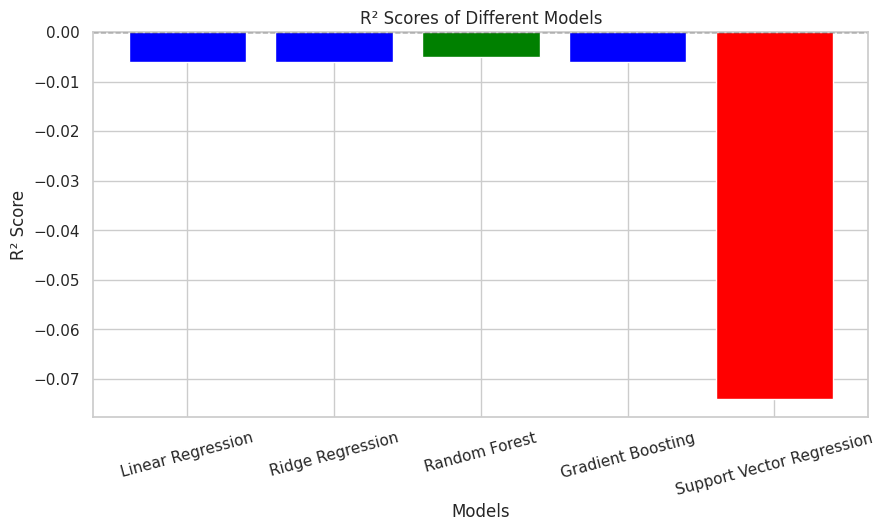

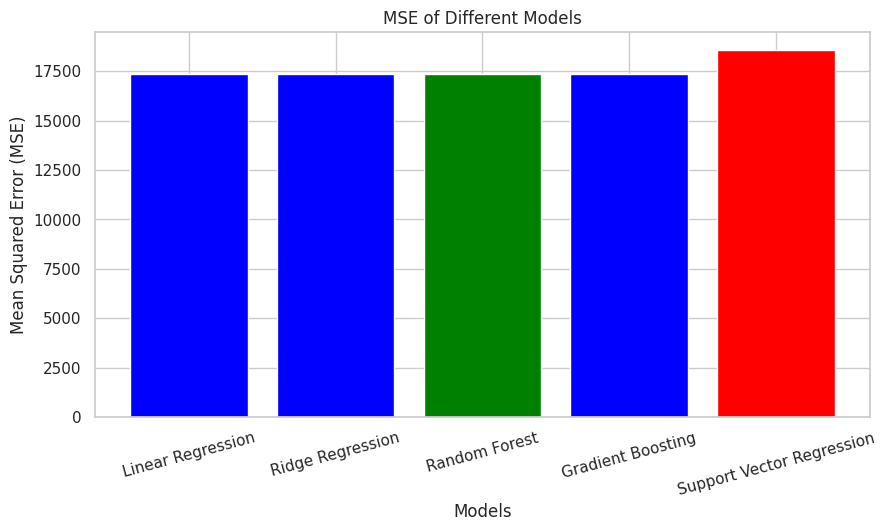

In [32]:
# Model names and their performance metrics
models = ["Linear Regression", "Ridge Regression", "Random Forest", "Gradient Boosting", "Support Vector Regression"]
r2_scores = [-0.006, -0.006, -0.005, -0.006, -0.074]
mse_scores = [17372.767, 17372.767, 17358.752, 17372.767, 18549.447]

# Plot R² Scores
plt.figure(figsize=(10, 5))
plt.bar(models, r2_scores, color=['blue', 'blue', 'green', 'blue', 'red'])
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("R² Scores of Different Models")
plt.xticks(rotation=15)
plt.show()

# Plot MSE Scores
plt.figure(figsize=(10, 5))
plt.bar(models, mse_scores, color=['blue', 'blue', 'green', 'blue', 'red'])
plt.xlabel("Models")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE of Different Models")
plt.xticks(rotation=15)
plt.show()


## Thank you....upvote pls